# Linear Regression Analysis on Ecommerce Customers Dataset

## Introduction
This project aims to analyze customer behavior in an e-commerce platform using Linear Regression.  
The goal is to understand how different user features affect the yearly amount spent by customers.  

By examining variables such as session length, time spent on the app, time spent on the website, and membership duration, we can identify which factors have the strongest impact on customer spending.  

This analysis helps businesses make better decisions to improve customer engagement and increase revenue.

In [1]:
import pandas as pd

df = pd.read_csv('Ecommerce Customers.csv')
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [3]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [4]:
df.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

In [5]:
X = df[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]
y = df['Yearly Amount Spent']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

In [7]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

In [8]:
predictions = lm.predict(X_test)

In [9]:
from sklearn import metrics
import numpy as np

print('MAE:', metrics.mean_absolute_error(y_test, predictions))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('R2:', metrics.r2_score(y_test, predictions))

MAE: 7.74267128583874
RMSE: 9.68674238370159
R2: 0.9855061240024658


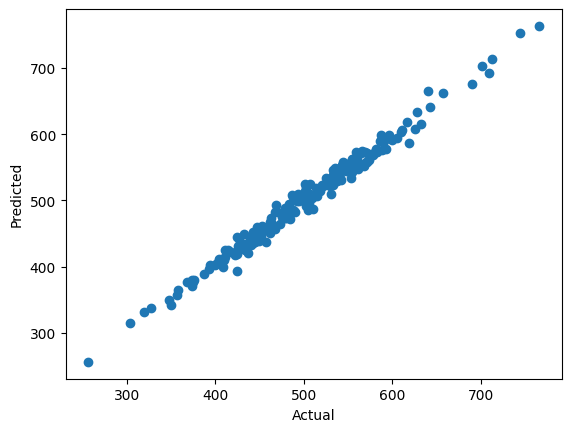

In [10]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()

The scatter plot shows a strong linear relationship between the actual and predicted values, which confirms the accuracy of the model.

## Data Cleaning
The dataset was checked for missing values and duplicates.  
No missing values or duplicate records were found, so no data cleaning was required.

## Exploratory Data Analysis (EDA)
The dataset was explored using `info()`, `describe()`, and `head()`.  
It contains 500 entries with both numerical and categorical features.  

A correlation analysis showed that:
- Length of Membership and Time on App have strong positive relationships with yearly spending.
- Time on Website has a weaker relationship.

## Feature Selection
The following numerical features were selected as independent variables:
- Avg. Session Length  
- Time on App  
- Time on Website  
- Length of Membership  

The target variable is:
- Yearly Amount Spent  

Text-based features such as Email, Address, and Avatar were excluded because they are not suitable for linear regression.

## Model Training
The dataset was split into training and testing sets (60% training, 40% testing).  
A Linear Regression model was trained using the training data.

## Model Evaluation
The model was evaluated using the following metrics:
- MAE ≈ 7.7  
- RMSE ≈ 9.6  
- R² ≈ 0.98  

This indicates that the model performs very well and explains about 98% of the variance.

## Conclusion
The Linear Regression model is highly effective for this dataset.  
The most important factor affecting yearly spending is Length of Membership, followed by Time on App.  

This suggests that long-term customers and users who spend more time on the mobile app tend to spend more money.